# Model For Emergency Service Satisfaction 

## Overview & Preprocessing Data

In [1]:
import numpy as np 
import pandas as pd 
import os 
def load_kaggle_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/datasets/', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path)
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/'+filename)

  
    
patientsData = load_kaggle_data("patients.csv","jaderz/hospital-beds-management")
services_weekly = load_kaggle_data("services_weekly.csv","jaderz/hospital-beds-management")
patientsData.head(10)


🏠 Running locally. Loading: patients.csv
🏠 Running locally. Loading: services_weekly.csv


,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76
5,PAT-f4b29bae,Diana May,83,2025-06-26,2025-06-30,emergency,81
6,PAT-283cda07,William Herrera,62,2025-12-26,2025-12-27,emergency,66
7,PAT-5b61868c,Ashley Waller,0,2025-05-21,2025-06-04,ICU,82
8,PAT-f9c8afa6,Victor Baker,50,2025-07-30,2025-08-13,general_medicine,91
9,PAT-5290be70,Jeffrey Chandler,29,2025-11-01,2025-11-14,emergency,88


In [2]:
patientsData.isnull().sum()

patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64

In [3]:
patientsData.describe()

,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000


In [4]:
from datetime import datetime

format = "%Y-%m-%d" 

def dayCounter(start_date,end_date):
    """
    It counts calculate to days between start_date and end_date
    """
    s = datetime.strptime(start_date,format)
    e = datetime.strptime(end_date,format)
    
    return (e-s).days

patientsData['day'] = patientsData.apply(lambda x :  dayCounter(x['arrival_date'],x['departure_date']),axis=1)



In [5]:
patientsData = patientsData.drop(['patient_id','name','arrival_date','departure_date'],axis=1)

In [6]:
patientsData = pd.get_dummies(patientsData,drop_first=True)
patientsData

,age,satisfaction,day,service_emergency,service_general_medicine,service_surgery
0,24,61,6,False,False,True
1,6,83,1,False,False,True
2,24,83,6,False,True,False
3,32,81,11,True,False,False
4,25,76,7,False,False,False
...,...,...,...,...,...,...
995,26,91,2,True,False,False
996,89,99,12,True,False,False
997,72,69,9,False,False,False
998,47,61,12,False,False,False


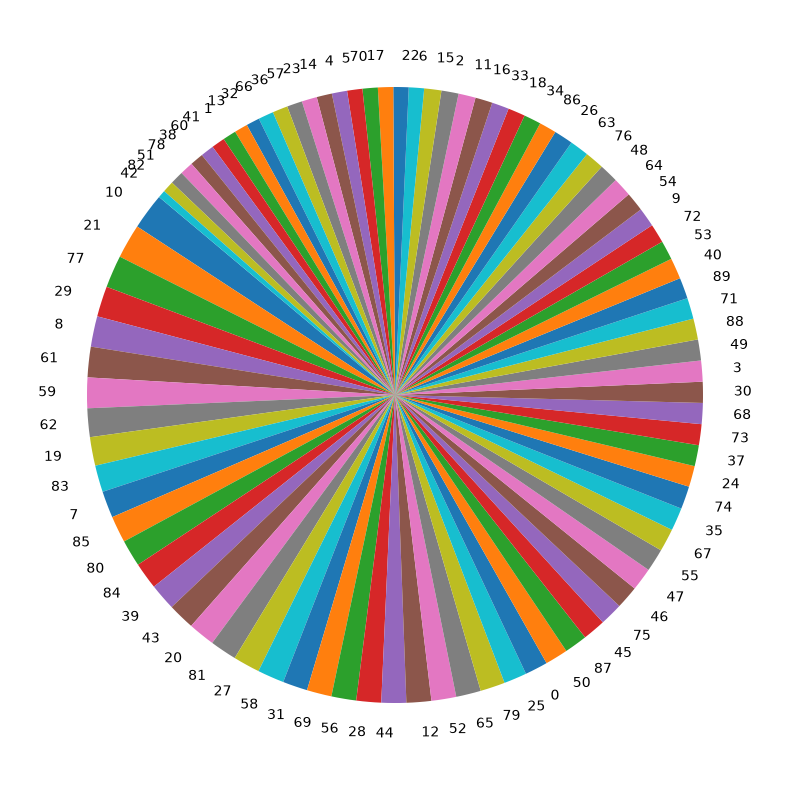

In [7]:
import matplotlib.pyplot as plt
import numpy as np


age_counts = patientsData.age.value_counts()
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Feed the data and the labels to the pie chart
plt.pie(
    age_counts, 
    labels=age_counts.index, 
    startangle=140      # Tilts the pie chart for a nicer starting view
)


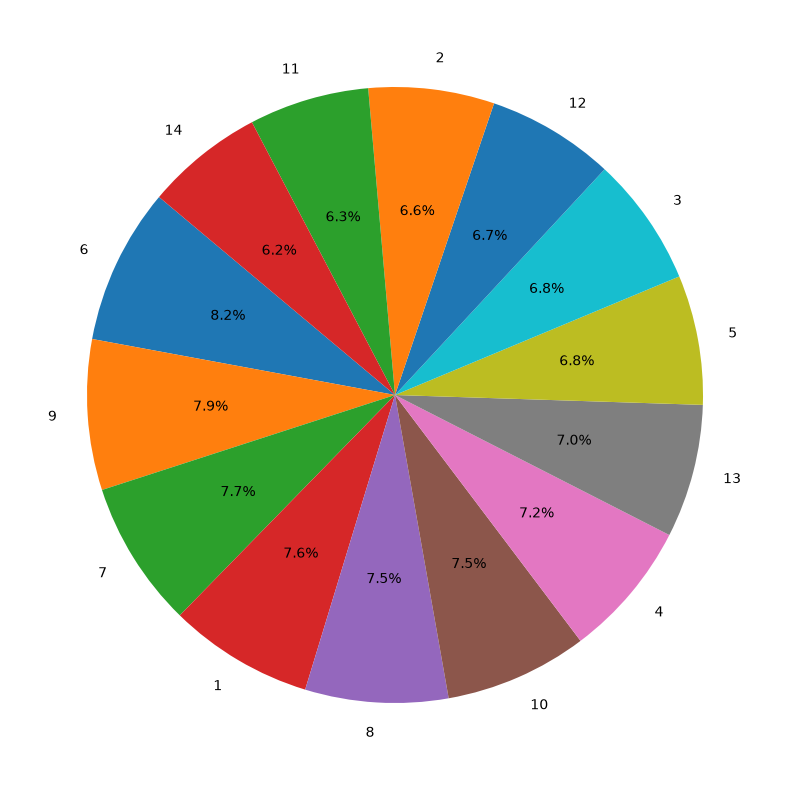

In [8]:

day_counts = patientsData.day.value_counts()
fig, ax = plt.subplots(figsize=(10, 10))


plt.pie(
    day_counts, 
    labels=day_counts.index,
    autopct="%1.1f%%", 
    startangle=140      
)


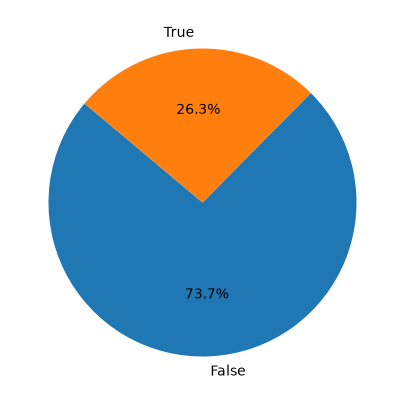

In [9]:

em_counts = patientsData.service_emergency.value_counts()
fig, ax = plt.subplots(figsize=(5,5))

# 3. Feed the data and the labels to the pie chart
plt.pie(
    em_counts, 
    labels=em_counts.index,
    autopct="%1.1f%%", 
    startangle=140      # Tilts the pie chart for a nicer starting view
)


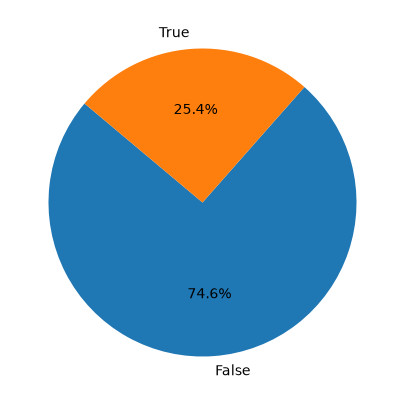

In [10]:
su_counts = patientsData.service_surgery.value_counts()
fig, ax = plt.subplots(figsize=(5,5))

# 3. Feed the data and the labels to the pie chart
plt.pie(
    su_counts, 
    labels=su_counts.index,
    autopct="%1.1f%%", 
    startangle=140      # Tilts the pie chart for a nicer starting view
)


In [11]:
staff = load_kaggle_data('staff.csv','jaderz/hospital-beds-management')

🏠 Running locally. Loading: staff.csv


In [12]:
staff.describe()

,staff_id,staff_name,role,service
count,110,110,110,110
unique,110,110,3,4
top,STF-5ca26577,Allison Hill,nurse,ICU
freq,1,1,69,32


In [13]:
staff.tail()

,staff_id,staff_name,role,service
105,STF-2c8a995d,Marc Moore,nursing_assistant,ICU
106,STF-251c7770,Sharon Cherry,nursing_assistant,ICU
107,STF-3fb56209,Sierra Johnson,nursing_assistant,ICU
108,STF-a8c30e00,Evelyn Galvan,nursing_assistant,ICU
109,STF-021fdf9f,Sharon Cochran,nursing_assistant,ICU


In [14]:
staff.role.value_counts()

role
nurse                69
nursing_assistant    23
doctor               18
Name: count, dtype: int64

In [15]:
staff.service.value_counts()

service
ICU                 32
emergency           29
general_medicine    27
surgery             22
Name: count, dtype: int64

In [16]:
sc = load_kaggle_data('staff_schedule.csv','jaderz/hospital-beds-management')

🏠 Running locally. Loading: staff_schedule.csv


##  Overview The Staff

In [17]:
roles_staffs = sc.groupby("role").staff_name.unique()
roles_staffs

role
doctor               [Allison Hill, Noah Rhodes, Angie Henderson, D...
nurse                [Gabrielle Davis, Ryan Munoz, Monica Herrera, ...
nursing_assistant    [Rebecca Henderson, James Ferrell, Tricia Vale...
Name: staff_name, dtype: object

In [18]:
roles_staffs["doctor"]

<StringArray>
[     'Allison Hill',       'Noah Rhodes',   'Angie Henderson',
     'Daniel Wagner',   'Cristian Santos',   'Connie Lawrence',
   'Abigail Shaffer',        'Gina Moore',   'Brittany Farmer',
      'Paula Moreno',        'Fred Smith',  'Jessica Callahan',
        'Amber Kidd',       'Tracy House',      'Carol Tucker',
       'James Brown',     'Denise Jacobs', 'Christina Walters',
    'John Whitehead',    'Anna Henderson',        'Aaron Wise',
  'Deborah Figueroa']
Length: 22, dtype: str

In [19]:
roles_staffs["nurse"]

<StringArray>
[     'Gabrielle Davis',           'Ryan Munoz',       'Monica Herrera',
         'Jamie Arnold',         'Lisa Hensley',     'Michele Williams',
         'Dylan Miller',        'Brian Ramirez',           'Holly Wood',
         'Derek Zuniga',         'Lisa Jackson',           'Carla Gray',
 'Margaret Hawkins DDS',          'Patty Perez',          'Ethan Adams',
         'Tommy Walter',       'Matthew Foster',           'Judy Baker',
         'Justin Baker',       'Stephanie Ross',        'Zachary Hicks',
    'Anthony Rodriguez',        'Sherry Decker',     'Anthony Humphrey',
      'Angelica Tucker',        'Philip Cannon',          'John Pierce',
      'Shane Henderson',         'Joshua Blair',          'Eric Carney',
       'Jessica Holmes',         'Danny Morgan',     'Crystal Robinson',
           'Mark Perez',        'Shannon Jones',        'Michael Lewis',
       'Timothy Duncan',      'Richard Aguirre',        'William Baker',
     'Jordan Henderson',       'Whitn

In [20]:
roles_staffs["nursing_assistant"]

<StringArray>
['Rebecca Henderson',     'James Ferrell',   'Tricia Valencia',
  'Nathan Maldonado',    'Debra Davidson',    'Jeffrey Chavez',
      'Sherri Baker',  'Cassandra Gaines',  'Elizabeth Fowler',
      'Brent Jordan',       'John Daniel',   'Victoria Garcia',
    'Gerald Hensley',       'Connor West',     'Donald Wright',
      'Daniel Baker',    'Shirley Suarez',  'Christopher Bass',
       'Lisa Archer',     'Aimee Montoya',  'Matthew Mcmillan',
   'Brian Rodriguez',     'Ashley Waller',      'Victor Baker',
  'Jeffrey Chandler',       'Larry Dixon',     'Kenneth Scott',
       'April Frost',   'Michelle Harmon',       'Helen Jones',
      'Erin Edwards']
Length: 31, dtype: str

## Weekly Emergency Staff Analysis

In [21]:
def week_overiew(week,service):
    """
  
    """
    cat = sc[(sc['week'] == week) & (sc['present'] == 1) & (sc['service'] == service)]
  
    return cat
week_overiew(0,"emergency").groupby("role")["service"].size()



Series([], Name: service, dtype: int64)

In [22]:
import pandas as pd

weekly_records = []

for x in range(1, 53):

    week_data = week_overiew(x, "emergency").groupby("role").size()
    
    # 3. Append the Series directly to our list
    weekly_records.append(week_data)

# 4. Build the final DataFrame all at once
# Pandas automatically aligns the Series labels to the column names!
df = pd.DataFrame(weekly_records,columns=["doctor","nurse","nursing_assistant"])


df = df.fillna(0)


df["sum"] = df.sum(axis=1)


df.index = range(0, 52)

df


,doctor,nurse,nursing_assistant,sum
0,8.0,18.0,9.0,35.0
1,8.0,21.0,8.0,37.0
2,0.0,0.0,0.0,0.0
3,7.0,21.0,8.0,36.0
4,7.0,20.0,8.0,35.0
5,0.0,0.0,0.0,0.0
6,7.0,21.0,7.0,35.0
7,8.0,19.0,9.0,36.0
8,0.0,0.0,0.0,0.0
9,6.0,21.0,8.0,35.0


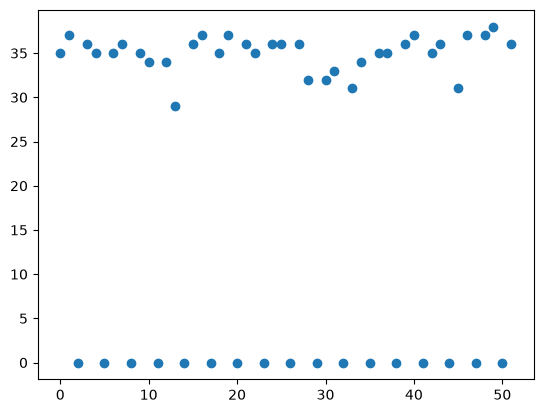

In [23]:
plt.scatter(np.arange(0,len(df)),df["sum"])

In [24]:
# 1. Convert 0 to NaN so they aren't counted in the average calculation
df_clean = df.replace(0, np.nan)

# 2. Fill those NaNs with the mean of each respective column
df = df_clean.fillna(df_clean.mean().round())

df.shape

(52, 4)

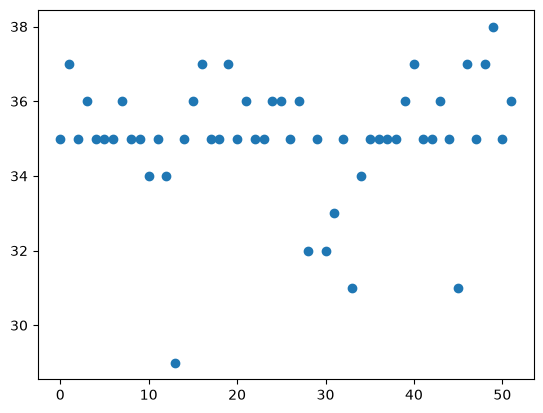

In [25]:

plt.scatter(np.arange(0,len(df)),df["sum"])


In [26]:
emergency_report =  services_weekly[(services_weekly["service"] ==  "emergency")]
emergency_report = emergency_report.drop(["month","event","service"],axis=1)
emergency_report

,week,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale
0,1,32,76,32,44,67,70
4,2,28,169,28,141,75,64
8,3,32,177,32,145,73,58
12,4,32,157,32,125,83,75
16,5,25,388,25,363,93,72
20,6,34,198,34,164,72,76
24,7,33,127,33,94,65,77
28,8,26,240,26,214,96,75
32,9,28,113,28,85,82,86
36,10,17,130,17,113,81,60


In [27]:
emergency_report["doctor"] = df.doctor.values
emergency_report["nurse"] = df.nurse.values
emergency_report["nursing_assistant"] = df.nursing_assistant.values
emergency_report

,week,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,doctor,nurse,nursing_assistant
0,1,32,76,32,44,67,70,8.0,18.0,9.0
4,2,28,169,28,141,75,64,8.0,21.0,8.0
8,3,32,177,32,145,73,58,7.0,20.0,8.0
12,4,32,157,32,125,83,75,7.0,21.0,8.0
16,5,25,388,25,363,93,72,7.0,20.0,8.0
20,6,34,198,34,164,72,76,7.0,20.0,8.0
24,7,33,127,33,94,65,77,7.0,21.0,7.0
28,8,26,240,26,214,96,75,8.0,19.0,9.0
32,9,28,113,28,85,82,86,7.0,20.0,8.0
36,10,17,130,17,113,81,60,6.0,21.0,8.0


## Data Visualation 

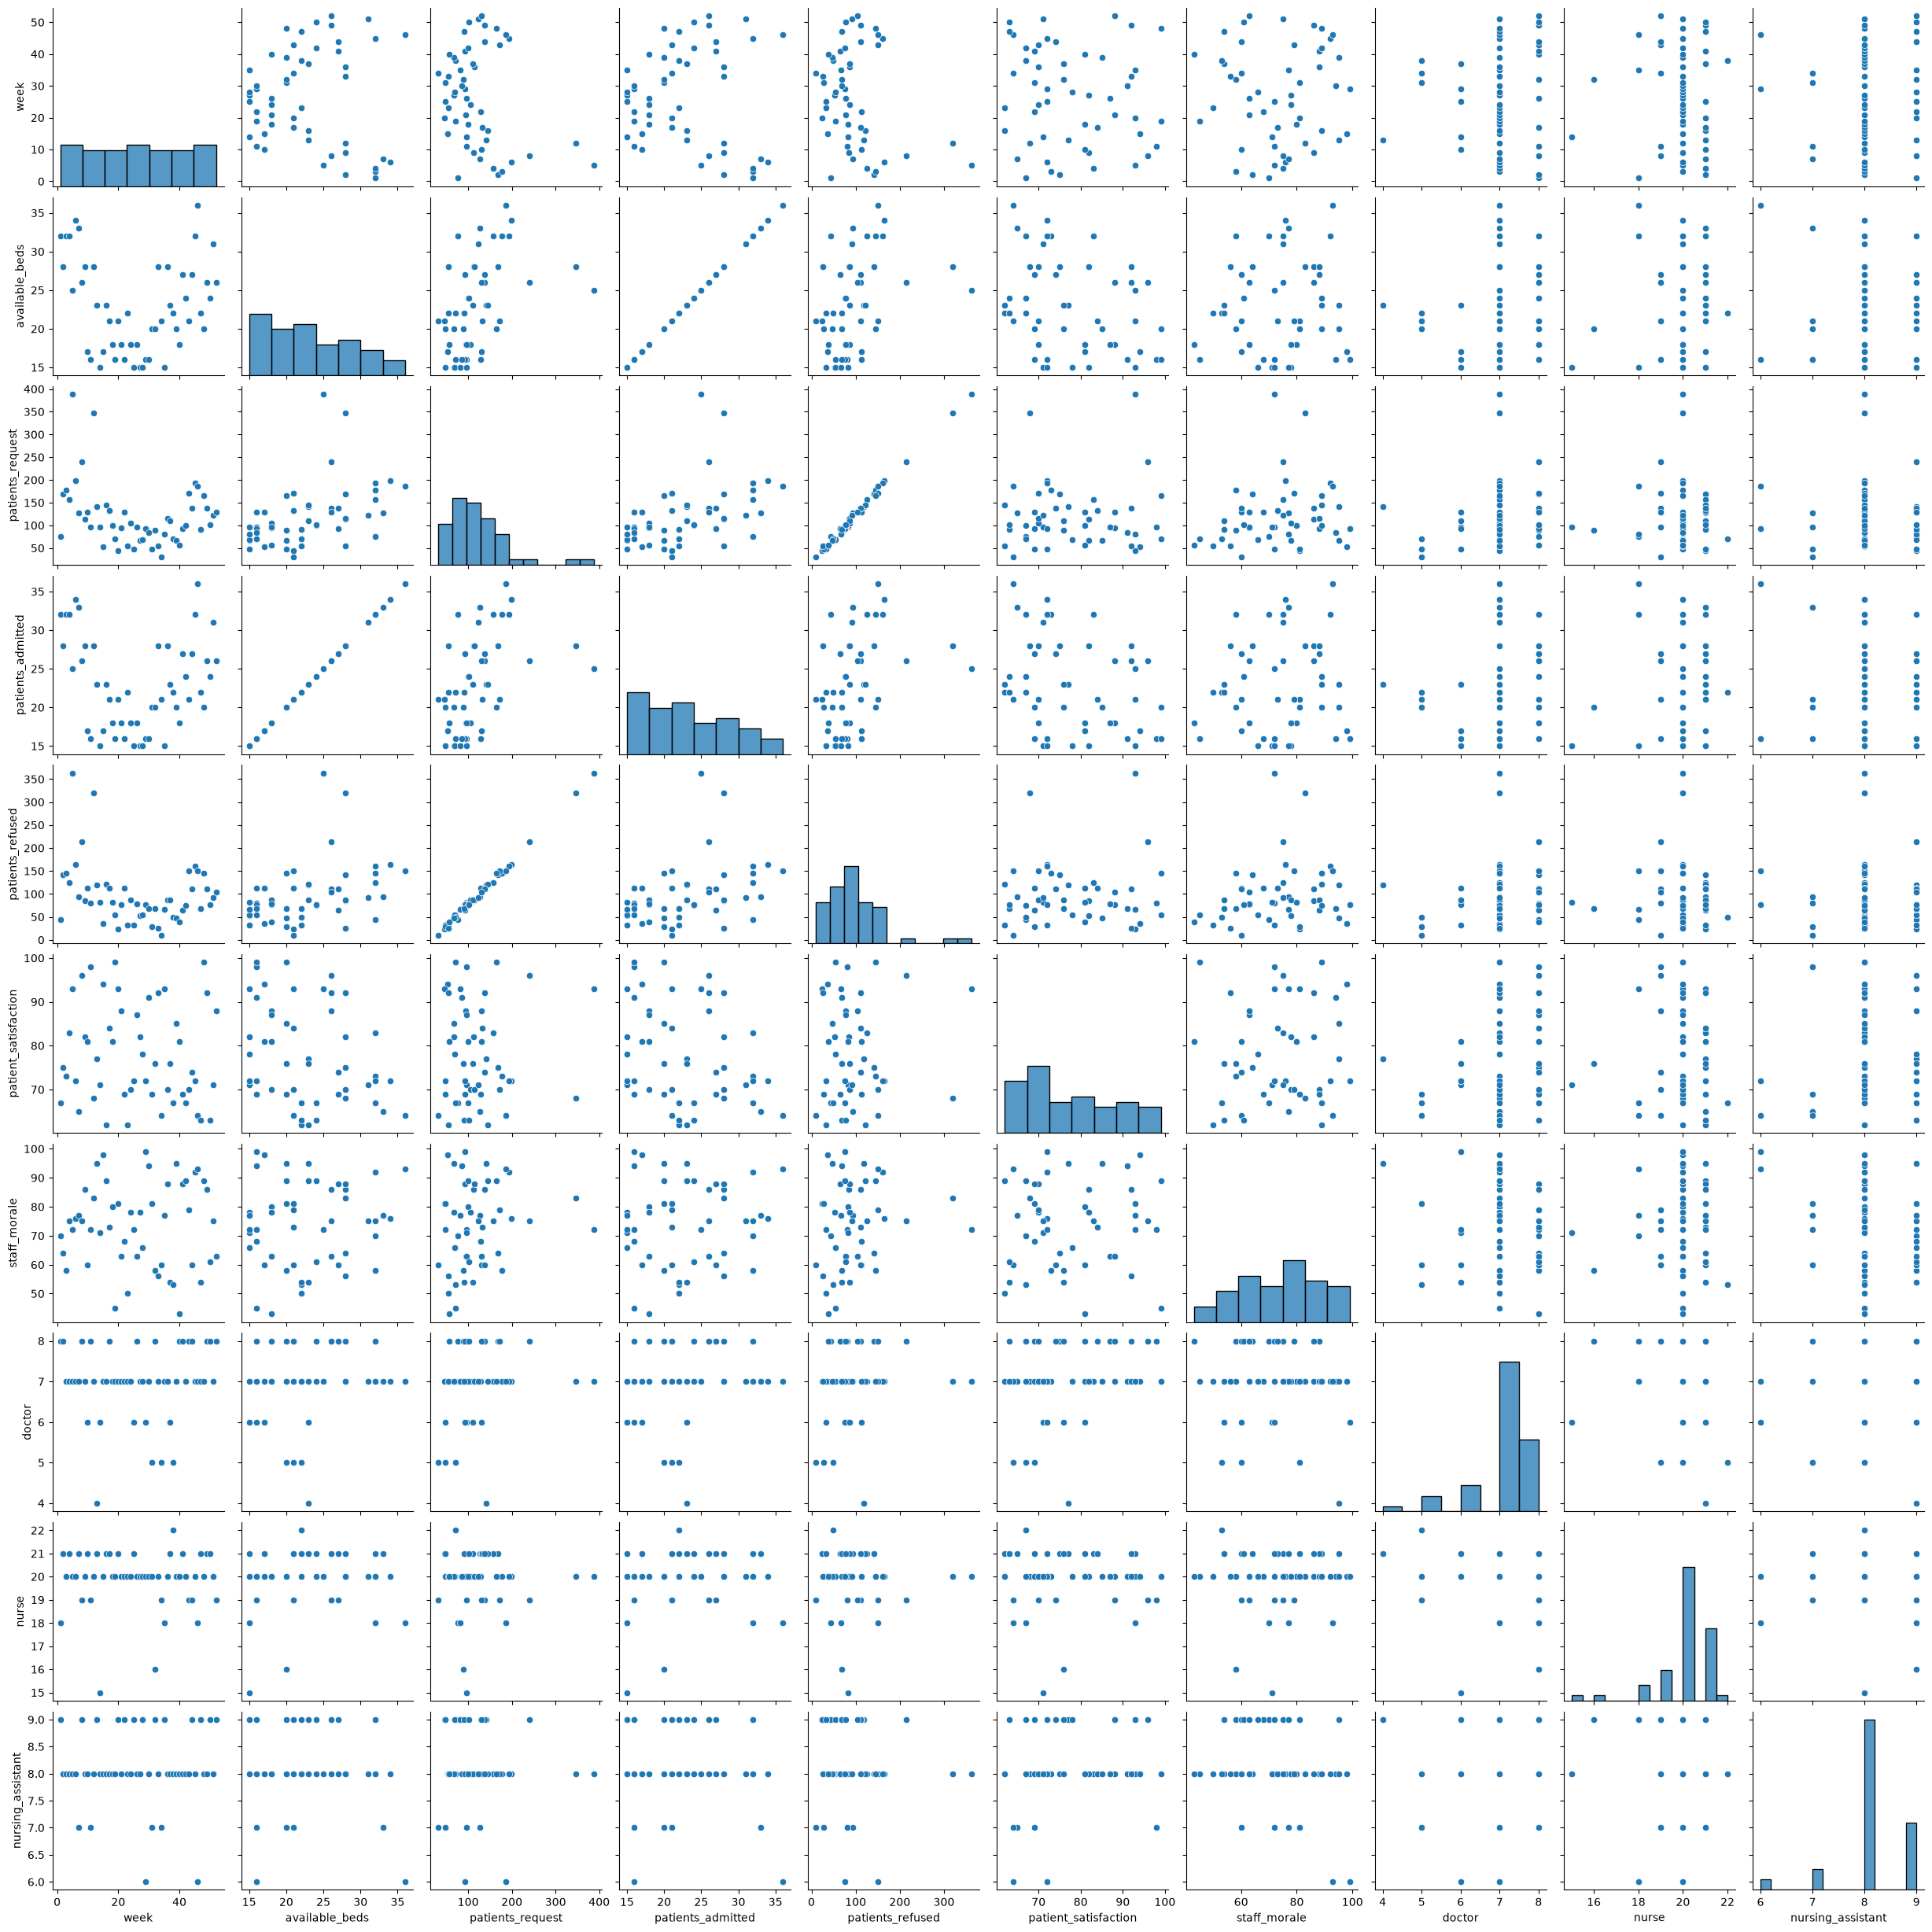

In [28]:
import seaborn as sns 
sns.pairplot(emergency_report)

In [29]:
emergency_report.isnull().sum()

week                    0
available_beds          0
patients_request        0
patients_admitted       0
patients_refused        0
patient_satisfaction    0
staff_morale            0
doctor                  0
nurse                   0
nursing_assistant       0
dtype: int64

## Data Correlation

In [30]:
emergency_report.corr().abs()["patient_satisfaction"].sort_values(ascending=False)

patient_satisfaction    1.000000
available_beds          0.314761
patients_admitted       0.314761
doctor                  0.233639
nursing_assistant       0.131550
week                    0.127082
patients_refused        0.064035
staff_morale            0.041583
patients_request        0.034171
nurse                   0.026821
Name: patient_satisfaction, dtype: float64

## The Features & Targets

In [31]:
X = emergency_report[["available_beds","patients_admitted","doctor","nursing_assistant","staff_morale","patients_request","nurse"]]
y = emergency_report.patient_satisfaction

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)


In [33]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor(max_depth=1,random_state=42)

RFR.fit(X_train,y_train)

y_pred = RFR.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(y_test,y_pred)

print(f"mae : {mae} | rmse {np.sqrt(mean_squared_error(y_test,y_pred))}")

mae : 9.109834149594203 | rmse 11.712550588267533


In [35]:
from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: -0.30578409995827793
